# Customer churn: does this data predict churn at all?

**Question.** Can we predict which subscribers will churn from demographics, plan length, monthly bill and usage,
so retention offers go to the right customers?

**Short answer: no.** Every feature has the same churn rate across its range, and every model scores at chance.
This notebook shows how to establish that rigorously (instead of reporting an overfit model), and what data would be needed.

**Data.** 100,000 subscribers, 9 columns ("Customer Churn Dataset", Kaggle). See `data/README.md`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
import lightgbm as lgb

sns.set_theme(style="whitegrid"); pd.set_option("display.precision", 4)
SEED = 42
df = pd.read_excel("data/customer_churn_large_dataset.xlsx")
NUM = ["Age", "Subscription_Length_Months", "Monthly_Bill", "Total_Usage_GB"]; CAT = ["Gender", "Location"]
print(df.shape, "| churn rate:", round(df.Churn.mean(), 4))

(100000, 9) | churn rate: 0.4978


## 1. Churn rate across each feature
If a feature matters, churn rate should move across its range. Numeric features are cut into deciles.
The chi-square test asks whether the churn rate differs across groups more than chance would allow.

In [2]:
rows, curves = [], {}
for c in NUM + CAT:
    grp = pd.qcut(df[c], 10, duplicates="drop") if c in NUM else df[c]
    rate = df.groupby(grp, observed=True).Churn.agg(["mean", "size"])
    p = stats.chi2_contingency(pd.crosstab(grp, df.Churn))[1]
    rows.append({"feature": c, "groups": len(rate), "min churn rate": rate["mean"].min(), "max churn rate": rate["mean"].max(), "chi-square p": p})
    curves[c] = rate["mean"].values
display(pd.DataFrame(rows).set_index("feature"))

Xd = pd.get_dummies(df[NUM + CAT], drop_first=True)
mi = pd.Series(mutual_info_classif(Xd, df.Churn, discrete_features=[c not in NUM for c in Xd.columns], random_state=SEED),
               index=Xd.columns).sort_values(ascending=False)
print("Six features tested: after a Bonferroni correction the significance threshold is 0.05 / 6 = 0.0083.")
print("mutual information with churn (0 = none):"); display(mi.round(5).to_frame("MI"))

,groups,min churn rate,max churn rate,chi-square p
feature,,,,
Age,10,0.4923,0.5032,0.7274
Subscription_Length_Months,10,0.4878,0.5040,0.6740
Monthly_Bill,10,0.4885,0.5058,0.2152
Total_Usage_GB,10,0.4895,0.5075,0.2213
Gender,2,0.4967,0.4989,0.5064
Location,5,0.4911,0.5037,0.0341


Six features tested: after a Bonferroni correction the significance threshold is 0.05 / 6 = 0.0083.
mutual information with churn (0 = none):


,MI
Monthly_Bill,4.2000e-04
Total_Usage_GB,3.8000e-04
Location_Houston,2.0000e-05
Location_New York,2.0000e-05
Location_Miami,1.0000e-05
Location_Los Angeles,1.0000e-05
Gender_Male,0.0000e+00
Age,0.0000e+00
Subscription_Length_Months,0.0000e+00


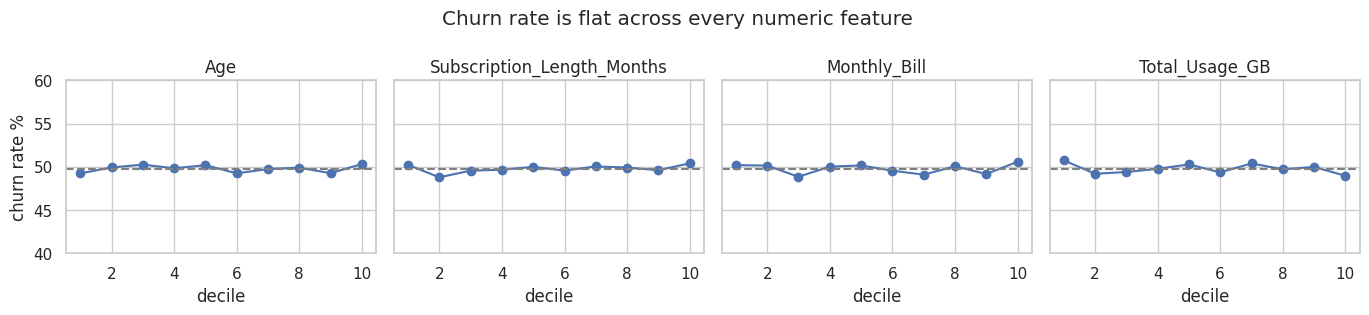

In [3]:
fig, axes = plt.subplots(1, len(NUM), figsize=(14, 3.2), sharey=True)
for ax, c in zip(axes, NUM):
    ax.plot(range(1, len(curves[c]) + 1), curves[c] * 100, marker="o"); ax.axhline(df.Churn.mean() * 100, ls="--", color="grey")
    ax.set_title(c); ax.set_xlabel("decile"); ax.set_ylim(40, 60)
axes[0].set_ylabel("churn rate %"); plt.suptitle("Churn rate is flat across every numeric feature")
plt.tight_layout(); plt.savefig("images/churn_by_decile.png", dpi=120); plt.show()

## 2. Models vs. a shuffled-label baseline
If the models only reach ROC-AUC 0.5, they are ranking customers at random. To be sure that isn't bad luck, the same
cross-validation is repeated with the churn labels **shuffled**, which shows what "no signal" looks like for this dataset size.

In [4]:
pre = ColumnTransformer([("num", StandardScaler(), NUM), ("cat", OneHotEncoder(), CAT)])
models = {"logistic regression": make_pipeline(pre, LogisticRegression(max_iter=1000)),
          "LightGBM": make_pipeline(pre, lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=SEED, verbose=-1))}
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
X, y = df[NUM + CAT], df.Churn
real = {m: cross_val_score(est, X, y, cv=cv, scoring="roc_auc") for m, est in models.items()}
rng = np.random.default_rng(SEED)
null = {m: np.array([cross_val_score(est, X, rng.permutation(y.values), cv=cv, scoring="roc_auc").mean() for _ in range(n)])
        for (m, est), n in zip(models.items(), [20, 10])}
display(pd.DataFrame({m: {"ROC-AUC (real labels)": real[m].mean(), "sd across folds": real[m].std(),
                          "shuffled labels: mean": null[m].mean(), "shuffled labels: max": null[m].max(), "shuffles": len(null[m])}
                      for m in models}).T)

,ROC-AUC (real labels),sd across folds,shuffled labels: mean,shuffled labels: max,shuffles
logistic regression,0.5026,0.0045,0.4999,0.5052,20.0
LightGBM,0.5054,0.0040,0.5000,0.5065,10.0


## 3. Conclusion
- Churn rate stays within a narrow band around the ~50% base rate across every feature decile and category (table above).
- Both models score at ROC-AUC ≈ 0.50, the same as with shuffled labels (differences are in the third decimal place). No useful relationship exists between these columns and churn.
- Location's p = 0.034 is the kind of false positive expected when testing six features; it doesn't survive a Bonferroni correction (threshold 0.0083).
- The first version of this project reported 99.98% training accuracy and 49% test accuracy: a decision tree memorising noise, not a model.

**What to collect instead.** Churn is usually driven by behaviour change and friction rather than static demographics:
usage trend (month-over-month change), support tickets and complaints, failed payments, contract type and time to renewal,
plan changes and discounts, and competitor offers. With those, the same pipeline (grouped features → CV → shuffled-label check) applies.